# **Retail Intelligence for a Small Footwear Business Using Data Analytics**
* This project applies data analytics and forecasting techniques to analyze sales and inventory performance in a small footwear retail business.

The coding sequence follows a proper Data Science pipeline:
  1. Data Loading
  2. Data Cleaning
  3. Feature Engineering
  4. Exploratory Data Analysis (EDA)
  5. Inventory Analysis
  6. Forecasting
  7. Model Evaluation




In [1]:
# from google.colab import files
# uploaded = files.upload()

## Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# **1. DATA LOADING**

## Loading the Dataset

In [3]:
df = pd.read_csv("raw_data.csv")

## Initial Data Inspection

In [4]:
df.head(10)

,Date,Product_Name,Category,Quantity_Sold,Cost_Price,Selling_Price,Profit,Remaining_Stock
0,1/24/2022,Ladies Flats Gold,Ladies,6.0,858.0,1734.0,5258.0,36.0
1,9/2/2022,Ladies Heels Red,Ladies,9.0,1235.0,2556.0,11884.0,33.0
2,4/7/2022,Sandals Summer,Casual,5.0,397.0,942.0,2723.0,14.0
3,1/27/2024,Jogging Shoes Puma,Sports,6.0,2530.0,3968.0,8628.0,63.0
4,6/11/2023,Formal Pump Ladies,Ladies,7.0,1554.0,2775.0,8552.0,112.0
5,2/26/2024,Running Shoes Nike Air,Sports,5.0,2874.0,4949.0,10375.0,21.0
6,3/21/2024,Casual Loafers Brown,Casual,11.0,868.0,1939.0,11781.0,53.0
7,10/16/2024,Ethnic Mojri,Ethnic,NaN,538.0,961.0,6345.0,56.0
8,11/17/2022,Ladies Flats Gold,Ladies,9.0,810.0,1570.0,6841.0,77.0
9,12/25/2024,Kids Sneakers Blue,Kids,NaN,557.0,1243.0,686.0,64.0


In [5]:
print(df.shape) # defining total number of rows and columns
print(df.info()) # defing the information about the data
print(df.describe()) # it is summarizing the data by statistically

(5952, 8)
<class 'pandas.DataFrame'>
RangeIndex: 5952 entries, 0 to 5951
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             5952 non-null   str    
 1   Product_Name     5835 non-null   str    
 2   Category         5834 non-null   str    
 3   Quantity_Sold    5597 non-null   float64
 4   Cost_Price       5692 non-null   float64
 5   Selling_Price    5683 non-null   float64
 6   Profit           5613 non-null   float64
 7   Remaining_Stock  5714 non-null   float64
dtypes: float64(5), str(3)
memory usage: 372.1 KB
None
       Quantity_Sold   Cost_Price  Selling_Price        Profit  \
count    5597.000000  5692.000000    5683.000000   5613.000000   
mean        8.309451  1423.689037    2716.690304   9872.473365   
std         4.782960  1055.996318    2981.272989   8783.741766   
min       -15.000000   230.000000     523.000000    264.000000   
25%         4.000000   570.000000    1167.000000  

# **2. DATA CLEANING**

## Checking Missing Values and Duplicate Records

In [6]:
print(df.isnull().sum())

Date                 0
Product_Name       117
Category           118
Quantity_Sold      355
Cost_Price         260
Selling_Price      269
Profit             339
Remaining_Stock    238
dtype: int64


In [7]:
print(df.duplicated().sum())

65


## Removing Duplicate Records

In [8]:
df = df.drop_duplicates()

## Checking data types of each column/Feature

In [9]:
df.dtypes

Date                   str
Product_Name           str
Category               str
Quantity_Sold      float64
Cost_Price         float64
Selling_Price      float64
Profit             float64
Remaining_Stock    float64
dtype: object

## Standardizing Category Values

In [10]:
category_mapping = {
    'forml': 'formal',
    'sprots': 'sports',
    'ladie': 'ladies',
    'kdis': 'kids',
    'casul': 'casual'
}


df['Category'] = (df['Category'].astype(str).str.lower().str.strip().replace(category_mapping))
df['Product_Name'] = df['Product_Name'].astype(str).str.lower().str.strip()

In [11]:
print(df['Category'].unique())  # Checking the unique category
print(df["Category"].nunique())

<StringArray>
['ladies', 'casual', 'sports', 'ethnic', 'kids', 'formal', nan]
Length: 7, dtype: str
6


In [12]:
print(df['Product_Name'].nunique()) # Getting Total Number of unique product
print(df["Product_Name"].unique())

15
<StringArray>
[     'ladies flats gold',       'ladies heels red',         'sandals summer',
     'jogging shoes puma',     'formal pump ladies', 'running shoes nike air',
   'casual loafers brown',           'ethnic mojri',     'kids sneakers blue',
      'kids formal black',    'casual canvas white',   'boots winter leather',
    'sports adidas ultra',    'formal oxford black',                      nan,
          'slippers home']
Length: 16, dtype: str


In [13]:
df.replace([" ", "NO", "Nan", "--", "NA"], np.nan, inplace=True)

,Date,Product_Name,Category,Quantity_Sold,Cost_Price,Selling_Price,Profit,Remaining_Stock
0,1/24/2022,ladies flats gold,ladies,6.0,858.0,1734.0,5258.0,36.0
1,9/2/2022,ladies heels red,ladies,9.0,1235.0,2556.0,11884.0,33.0
2,4/7/2022,sandals summer,casual,5.0,397.0,942.0,2723.0,14.0
3,1/27/2024,jogging shoes puma,sports,6.0,2530.0,3968.0,8628.0,63.0
4,6/11/2023,formal pump ladies,ladies,7.0,1554.0,2775.0,8552.0,112.0
...,...,...,...,...,...,...,...,...
5947,7/3/2024,casual canvas white,casual,11.0,517.0,1130.0,6741.0,42.0
5948,8/27/2023,jogging shoes puma,sports,12.0,2671.0,4398.0,20728.0,98.0
5949,10/26/2022,sandals summer,casual,1.0,385.0,965.0,580.0,80.0
5950,4/27/2023,kids formal black,kids,14.0,665.0,1478.0,11377.0,47.0


In [14]:
df.isnull().sum()

Date                 0
Product_Name       117
Category           117
Quantity_Sold      350
Cost_Price         258
Selling_Price      265
Profit             335
Remaining_Stock    236
dtype: int64

## Handling Missing Values

In [15]:
df['Product_Name'] = df['Product_Name'].fillna(df['Product_Name'].mode()[0])
df["Category"]= df["Category"].fillna(df["Category"].mode()[0])
df['Quantity_Sold'] = df['Quantity_Sold'].fillna(df['Quantity_Sold'].mean())
df['Cost_Price'] = df['Cost_Price'].fillna(df['Cost_Price'].mean())
df['Selling_Price'] = df['Selling_Price'].fillna(df['Selling_Price'].mean())
df['Profit'] = df['Profit'].fillna(df['Profit'].mean())
df['Remaining_Stock'] = df['Remaining_Stock'].fillna(df['Remaining_Stock'].mean())

In [16]:
df.isnull().sum()

Date               0
Product_Name       0
Category           0
Quantity_Sold      0
Cost_Price         0
Selling_Price      0
Profit             0
Remaining_Stock    0
dtype: int64

In [17]:
df.head(10)

,Date,Product_Name,Category,Quantity_Sold,Cost_Price,Selling_Price,Profit,Remaining_Stock
0,1/24/2022,ladies flats gold,ladies,6.000000,858.0,1734.0,5258.0,36.0
1,9/2/2022,ladies heels red,ladies,9.000000,1235.0,2556.0,11884.0,33.0
2,4/7/2022,sandals summer,casual,5.000000,397.0,942.0,2723.0,14.0
3,1/27/2024,jogging shoes puma,sports,6.000000,2530.0,3968.0,8628.0,63.0
4,6/11/2023,formal pump ladies,ladies,7.000000,1554.0,2775.0,8552.0,112.0
5,2/26/2024,running shoes nike air,sports,5.000000,2874.0,4949.0,10375.0,21.0
6,3/21/2024,casual loafers brown,casual,11.000000,868.0,1939.0,11781.0,53.0
7,10/16/2024,ethnic mojri,ethnic,8.315514,538.0,961.0,6345.0,56.0
8,11/17/2022,ladies flats gold,ladies,9.000000,810.0,1570.0,6841.0,77.0
9,12/25/2024,kids sneakers blue,kids,8.315514,557.0,1243.0,686.0,64.0


## Data Type Conversion and Date Formatting

In [18]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed', errors='coerce')
df["Quantity_Sold"] = df["Quantity_Sold"].astype(int)
df["Cost_Price"] = df["Cost_Price"].astype(int)
df["Selling_Price"] = df["Selling_Price"].astype(int)
df["Profit"] = df["Profit"].astype(int)
df["Remaining_Stock"]= df["Remaining_Stock"].astype(int)

In [19]:
df

,Date,Product_Name,Category,Quantity_Sold,Cost_Price,Selling_Price,Profit,Remaining_Stock
0,2022-01-24,ladies flats gold,ladies,6,858,1734,5258,36
1,2022-02-09,ladies heels red,ladies,9,1235,2556,11884,33
2,2022-07-04,sandals summer,casual,5,397,942,2723,14
3,2024-01-27,jogging shoes puma,sports,6,2530,3968,8628,63
4,2023-11-06,formal pump ladies,ladies,7,1554,2775,8552,112
...,...,...,...,...,...,...,...,...
5947,2024-03-07,casual canvas white,casual,11,517,1130,6741,42
5948,2023-08-27,jogging shoes puma,sports,12,2671,4398,20728,98
5949,2022-10-26,sandals summer,casual,1,385,965,580,80
5950,2023-04-27,kids formal black,kids,14,665,1478,11377,47


# **3. FEATURE ENGINEERING**

## Feature Engineering
* New features such as Month and Year were extracted from the Date column to support trend analysis and forecasting.

In [20]:
df['Month'] = df['Date'].dt.month

In [21]:
df['Year'] = df['Date'].dt.year

## Finally reviewing data to see few initial rows

In [22]:
print(df.head())

        Date        Product_Name Category  Quantity_Sold  Cost_Price  \
0 2022-01-24   ladies flats gold   ladies              6         858   
1 2022-02-09    ladies heels red   ladies              9        1235   
2 2022-07-04      sandals summer   casual              5         397   
3 2024-01-27  jogging shoes puma   sports              6        2530   
4 2023-11-06  formal pump ladies   ladies              7        1554   

   Selling_Price  Profit  Remaining_Stock  Month  Year  
0           1734    5258               36      1  2022  
1           2556   11884               33      2  2022  
2            942    2723               14      7  2022  
3           3968    8628               63      1  2024  
4           2775    8552              112     11  2023  


In [23]:
df.columns

Index(['Date', 'Product_Name', 'Category', 'Quantity_Sold', 'Cost_Price',
       'Selling_Price', 'Profit', 'Remaining_Stock', 'Month', 'Year'],
      dtype='str')

## Revenue Calculation

In [24]:
df["Revenue"] = df["Quantity_Sold"] * df["Selling_Price"]

In [25]:
df.head()

,Date,Product_Name,Category,Quantity_Sold,Cost_Price,Selling_Price,Profit,Remaining_Stock,Month,Year,Revenue
0,2022-01-24,ladies flats gold,ladies,6,858,1734,5258,36,1,2022,10404
1,2022-02-09,ladies heels red,ladies,9,1235,2556,11884,33,2,2022,23004
2,2022-07-04,sandals summer,casual,5,397,942,2723,14,7,2022,4710
3,2024-01-27,jogging shoes puma,sports,6,2530,3968,8628,63,1,2024,23808
4,2023-11-06,formal pump ladies,ladies,7,1554,2775,8552,112,11,2023,19425


In [26]:
print(df['Revenue'].sum()) # Calculating total Revenue
print(df['Profit'].sum()) # Calculating total Profit

134487517
58138731


In [27]:
print(df['Profit'].mean()) # Calculating Average Profit

9875.782401902497


# **4. EXPLORATORY DATA ANALYSIS (EDA)**

## Top Selling Products Analysis

In [28]:
top_products = df.groupby('Product_Name')['Quantity_Sold'].sum().sort_values(ascending=False)

top_products.head(10)

Product_Name
casual loafers brown    4366
sports adidas ultra     3605
boots winter leather    3412
kids sneakers blue      3355
jogging shoes puma      3324
ladies flats gold       3225
formal oxford black     3217
formal pump ladies      3199
sandals summer          3166
ladies heels red        3133
Name: Quantity_Sold, dtype: int64

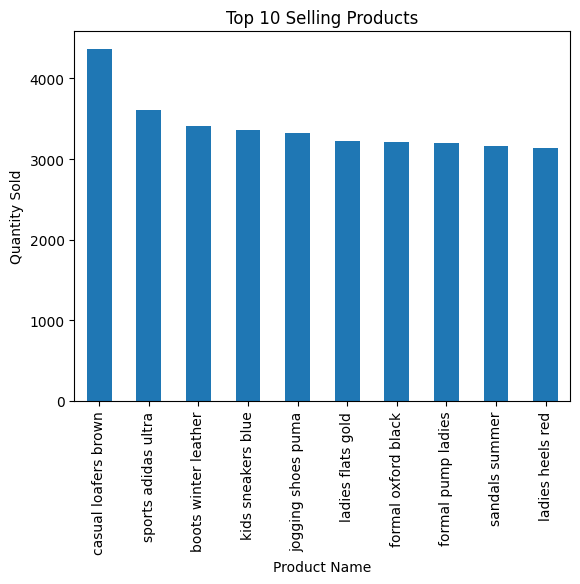

In [29]:
top_products.head(10).plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Quantity Sold')

plt.show()

## Category-wise Revenue Analysis

In [30]:
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

category_revenue

Category
sports    47190945
formal    33253712
ladies    23517158
casual    17831399
kids       9182398
ethnic     3511905
Name: Revenue, dtype: int64

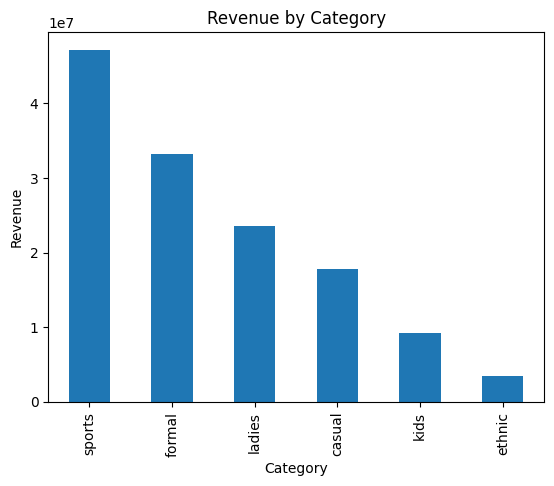

In [31]:
category_revenue.plot(kind='bar')

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.show()

## Month wise revenue / Seasonal Revenue

In [32]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
1     11831196
2     10164543
3     11724525
4     12018326
5     11270308
6     10655412
7     10913940
8      9579088
9     10627920
10    11680689
11    12625176
12    11396394
Name: Revenue, dtype: int64

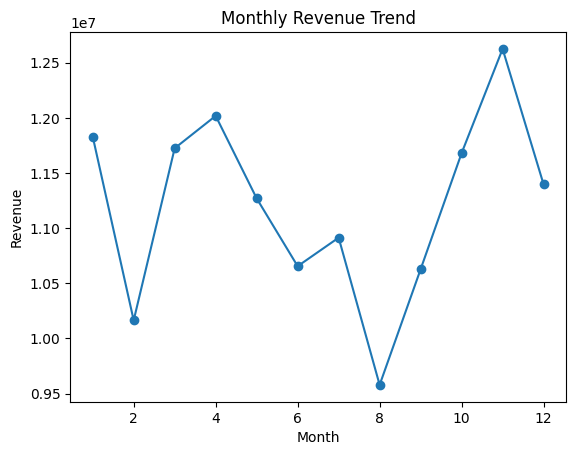

In [33]:
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

## Top Profitable Products

In [34]:
top_profit = df.groupby('Product_Name')['Profit'].sum().sort_values(ascending=False)

top_profit.head(10)

Product_Name
boots winter leather      8938855
sports adidas ultra       7378789
jogging shoes puma        5332727
running shoes nike air    5309485
formal oxford black       4659756
casual loafers brown      4415093
formal pump ladies        4342589
ladies heels red          3982939
ladies flats gold         2753297
kids formal black         2330197
Name: Profit, dtype: int64

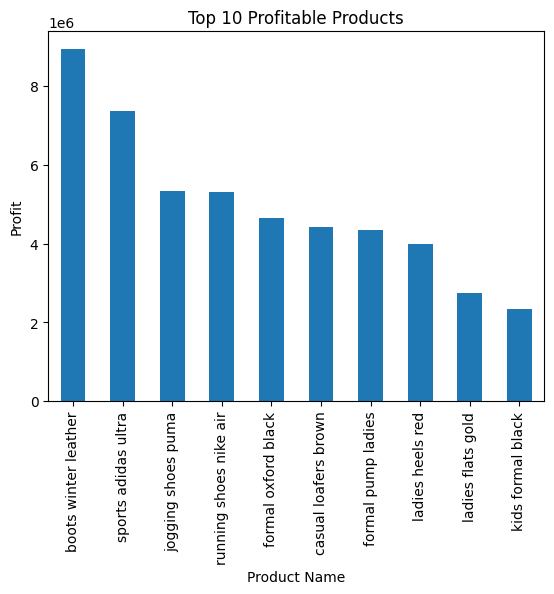

In [35]:
top_profit.head(10).plot(kind='bar')

plt.title('Top 10 Profitable Products')
plt.xlabel('Product Name')
plt.ylabel('Profit')

plt.show()

#**5. INVENTORY ANALYSIS**

## CALCULATING THE TOTAL QUANTITY SOLD PER PRODUCT

In [36]:
product_sales = df.groupby('Product_Name')['Quantity_Sold'].sum().sort_values(ascending=False)

product_sales.head(10)

Product_Name
casual loafers brown    4366
sports adidas ultra     3605
boots winter leather    3412
kids sneakers blue      3355
jogging shoes puma      3324
ladies flats gold       3225
formal oxford black     3217
formal pump ladies      3199
sandals summer          3166
ladies heels red        3133
Name: Quantity_Sold, dtype: int64

## Fast-moving Products

In [37]:
fast_moving = product_sales.head(10)

fast_moving

Product_Name
casual loafers brown    4366
sports adidas ultra     3605
boots winter leather    3412
kids sneakers blue      3355
jogging shoes puma      3324
ladies flats gold       3225
formal oxford black     3217
formal pump ladies      3199
sandals summer          3166
ladies heels red        3133
Name: Quantity_Sold, dtype: int64

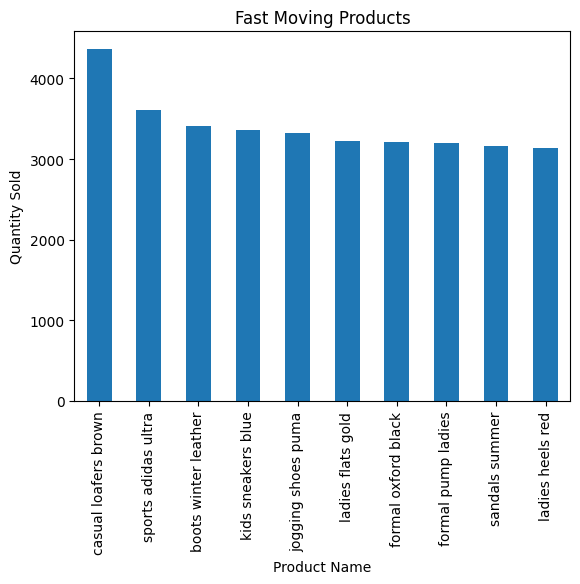

In [38]:
fast_moving.plot(kind='bar')

plt.title('Fast Moving Products')
plt.xlabel('Product Name')
plt.ylabel('Quantity Sold')

plt.show()

## Slow-moving Products

In [39]:
slow_moving = product_sales.tail(10)

slow_moving

Product_Name
ladies flats gold         3225
formal oxford black       3217
formal pump ladies        3199
sandals summer            3166
ladies heels red          3133
running shoes nike air    3068
ethnic mojri              3062
casual canvas white       2994
kids formal black         2969
slippers home             2748
Name: Quantity_Sold, dtype: int64

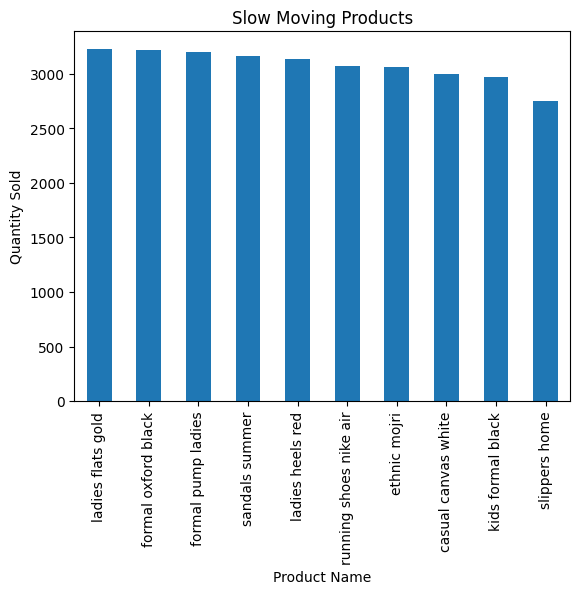

In [40]:
slow_moving.plot(kind='bar')

plt.title('Slow Moving Products')
plt.xlabel('Product Name')
plt.ylabel('Quantity Sold')

plt.show()

## Inventory Turnover Analysis
* CALCULATE INVENTORY TURNOVER INDICATOR / viewing ratio of how fast product is sold



In [41]:
df['Turnover_Ratio'] = df['Quantity_Sold'] / (df['Remaining_Stock'] + 1)

## Top Inventory Turnover Products

In [42]:
top_turnover = df.groupby('Product_Name')['Turnover_Ratio'].mean().sort_values(ascending=False)

top_turnover.head(10)

Product_Name
jogging shoes puma        0.203727
running shoes nike air    0.196287
sports adidas ultra       0.194617
casual loafers brown      0.190059
casual canvas white       0.188465
ladies flats gold         0.188191
kids sneakers blue        0.185582
formal pump ladies        0.185352
boots winter leather      0.185219
formal oxford black       0.182424
Name: Turnover_Ratio, dtype: float64

## ABC Inventory Classification

In [43]:
abc = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).reset_index()

## Calculating Revenue Contribution Percentage

In [44]:
abc['Cumulative_Percentage'] = abc['Revenue'].cumsum() / abc['Revenue'].sum() * 100

In [45]:
print(abc.head(10))

             Product_Name   Revenue  Cumulative_Percentage
0    boots winter leather  21459000              15.956128
1     sports adidas ultra  19299691              30.306672
2  running shoes nike air  14602154              41.164300
3      jogging shoes puma  13508274              51.208559
4     formal oxford black  11321305              59.626667
5      formal pump ladies   9696877              66.836910
6    casual loafers brown   9229480              73.699614
7        ladies heels red   8326313              79.890756
8       ladies flats gold   5666833              84.104406
9       kids formal black   4598128              87.523406


In [46]:
print(abc.tail(10))

            Product_Name  Revenue  Cumulative_Percentage
5     formal pump ladies  9696877              66.836910
6   casual loafers brown  9229480              73.699614
7       ladies heels red  8326313              79.890756
8      ladies flats gold  5666833              84.104406
9      kids formal black  4598128              87.523406
10    kids sneakers blue  4535496              90.895835
11   casual canvas white  3623910              93.590442
12          ethnic mojri  3478236              96.176731
13        sandals summer  3253948              98.596247
14         slippers home  1887872             100.000000


## Creating ABC Classification Function

In [47]:
def abc_class(x):
    if x <= 70:
        return 'A'
    elif x <= 90:
        return 'B'
    else:
        return 'C'

abc['Class'] = abc['Cumulative_Percentage'].apply(abc_class)

In [48]:
abc.head(20)

,Product_Name,Revenue,Cumulative_Percentage,Class
0,boots winter leather,21459000,15.956128,A
1,sports adidas ultra,19299691,30.306672,A
2,running shoes nike air,14602154,41.164300,A
3,jogging shoes puma,13508274,51.208559,A
4,formal oxford black,11321305,59.626667,A
5,formal pump ladies,9696877,66.836910,A
6,casual loafers brown,9229480,73.699614,B
7,ladies heels red,8326313,79.890756,B
8,ladies flats gold,5666833,84.104406,B
9,kids formal black,4598128,87.523406,B


## Distribution of ABC Classes

In [49]:
abc['Class'].value_counts()

Class
A    6
C    5
B    4
Name: count, dtype: int64

## Visualization of ABC Analysis

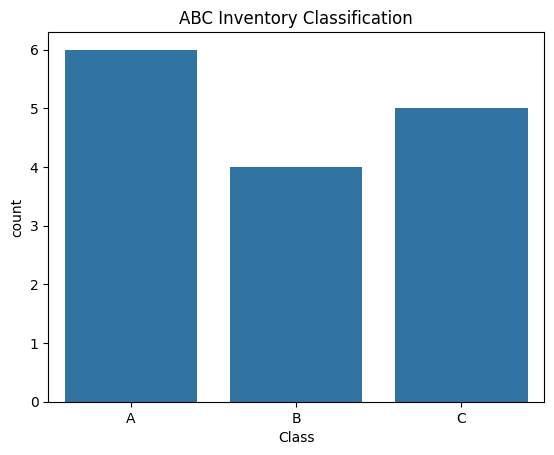

In [ ]:
sns.countplot(x='Class', data=abc)

plt.title('ABC Inventory Classification')

plt.show()



# Correlation Analysis

In [51]:
correlation = df[['Quantity_Sold', 'Selling_Price', 'Profit', 'Revenue', 'Remaining_Stock']].corr()

correlation

,Quantity_Sold,Selling_Price,Profit,Revenue,Remaining_Stock
Quantity_Sold,1.000000,0.022469,0.612830,0.468477,0.013911
Selling_Price,0.022469,1.000000,0.369419,0.747931,0.006634
Profit,0.612830,0.369419,1.000000,0.675004,0.021428
Revenue,0.468477,0.747931,0.675004,1.000000,0.014165
Remaining_Stock,0.013911,0.006634,0.021428,0.014165,1.000000


## Correlation Heatmap

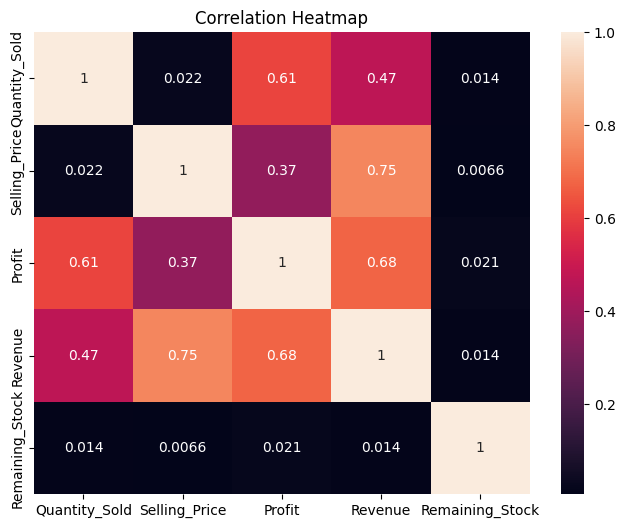

In [52]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True)

plt.title('Correlation Heatmap')

plt.show()

# **6. FORECASTING**

# **Time Series Forecasting**

## Monthly Revenue Aggregation

In [53]:
monthly_data = df.resample('ME', on='Date')['Revenue'].sum()

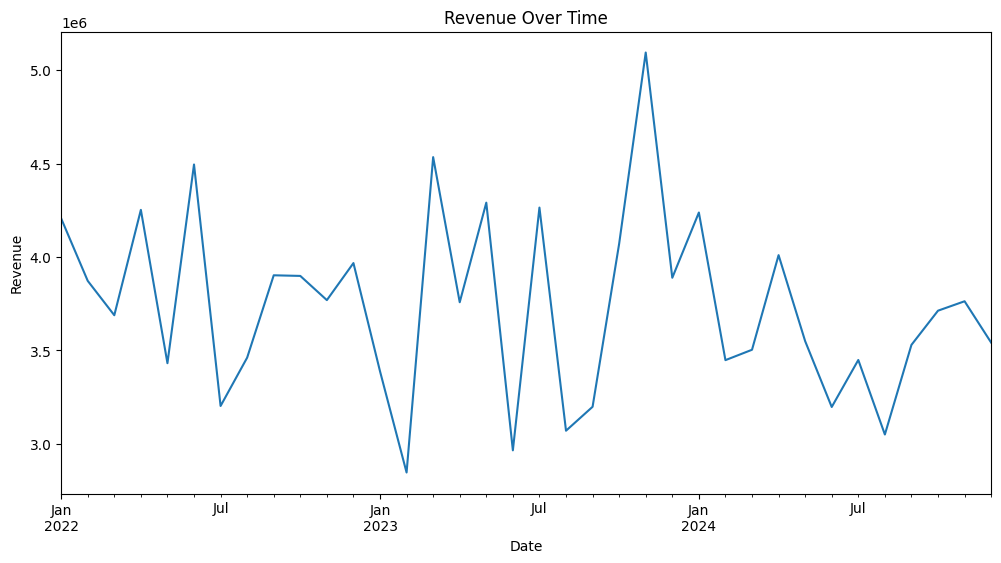

In [54]:
plt.figure(figsize=(12,6))

monthly_data.plot()

plt.title('Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.show()

## Train-Test Split

In [55]:
train_size = int(len(monthly_data) * 0.8)

train = monthly_data[:train_size]
test = monthly_data[train_size:]

## Train-Test Data Visualization

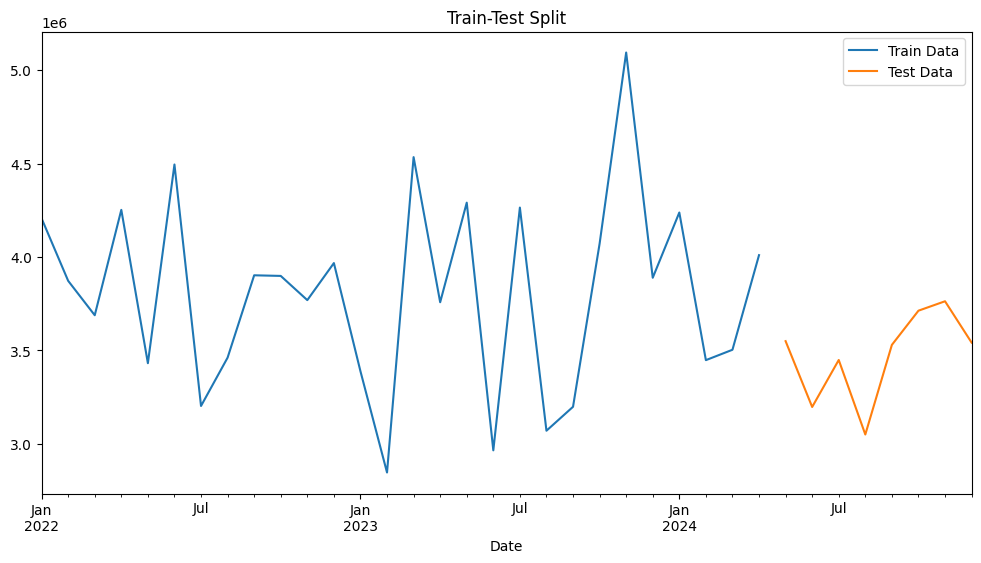

In [56]:
plt.figure(figsize=(12,6))

train.plot(label='Train Data')
test.plot(label='Test Data')

plt.legend()

plt.title('Train-Test Split')

plt.show()

## Moving Average Forecasting

In [57]:
moving_avg = train.rolling(window=7).mean()

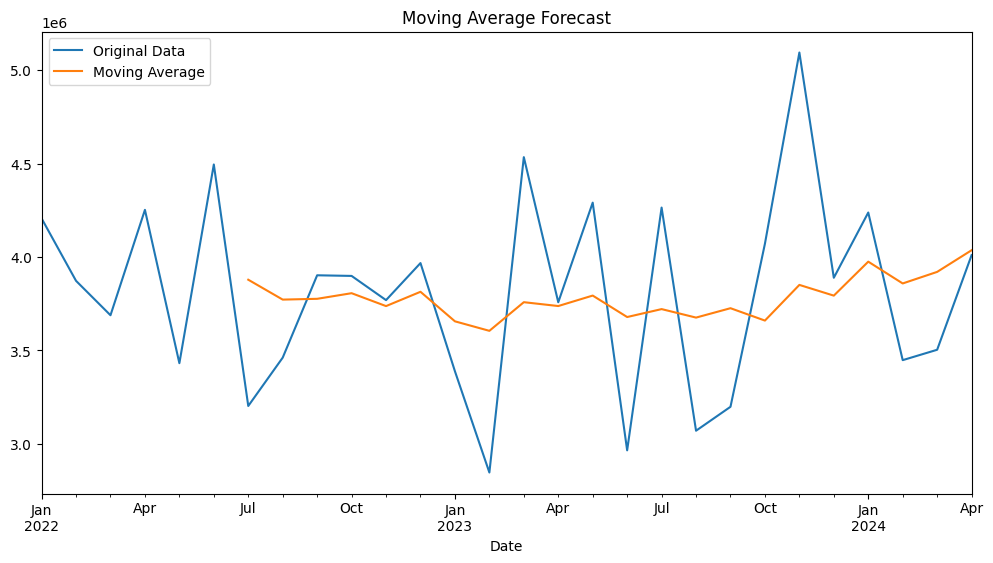

In [58]:
plt.figure(figsize=(12,6))

train.plot(label='Original Data')
moving_avg.plot(label='Moving Average')

plt.legend()

plt.title('Moving Average Forecast')

plt.show()

## Building the ARIMA Forecasting Model

In [59]:
model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

## Forecast Generation

In [60]:
forecast = model_fit.forecast(steps=len(test))


In [61]:
# print("Forecast value is", forecast.sum())
# print("Actual value is", test.sum())
# print("Mean of the actual value is: ", test.mean())

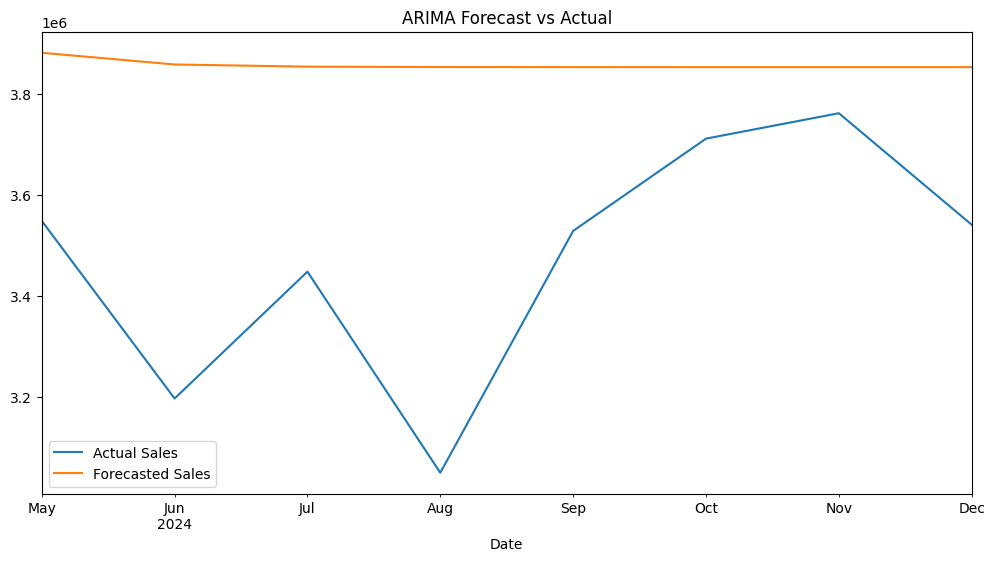

In [62]:
plt.figure(figsize=(12,6))

test.plot(label='Actual Sales')
forecast.plot(label='Forecasted Sales')

plt.legend()

plt.title('ARIMA Forecast vs Actual')

plt.show()

# **7. FORECAST MODEL EVALUATION**

## Mean Absolute Error (MAE)

In [63]:
mae = mean_absolute_error(test, forecast)

mae

384847.2444022054

## Root Mean Squared Error (RMSE)

In [64]:
rmse = np.sqrt(mean_squared_error(test, forecast))

rmse

np.float64(446594.7359274181)

## Mean Absolute Percentage Error (MAPE)

In [65]:
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(mape)

11.576743890696967


# Final Forecasting Results

In [66]:
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 384847.2444022054
RMSE: 446594.7359274181
MAPE: 11.576743890696967


In [69]:
df.to_csv("cleaned_data", index= False)